<a href="https://colab.research.google.com/github/HenryZumaeta/py4cd_EPC2025/blob/main/C18/C18_Script01_EstadisticaInferencial_III.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Velocidad de la convergencia

# Ejemplito 01:

**Enunciado** :  Los tiempos de espera para un servicio automatizado que responde en cualquier momento dentro de un intervalo fijo de 1 minuto.

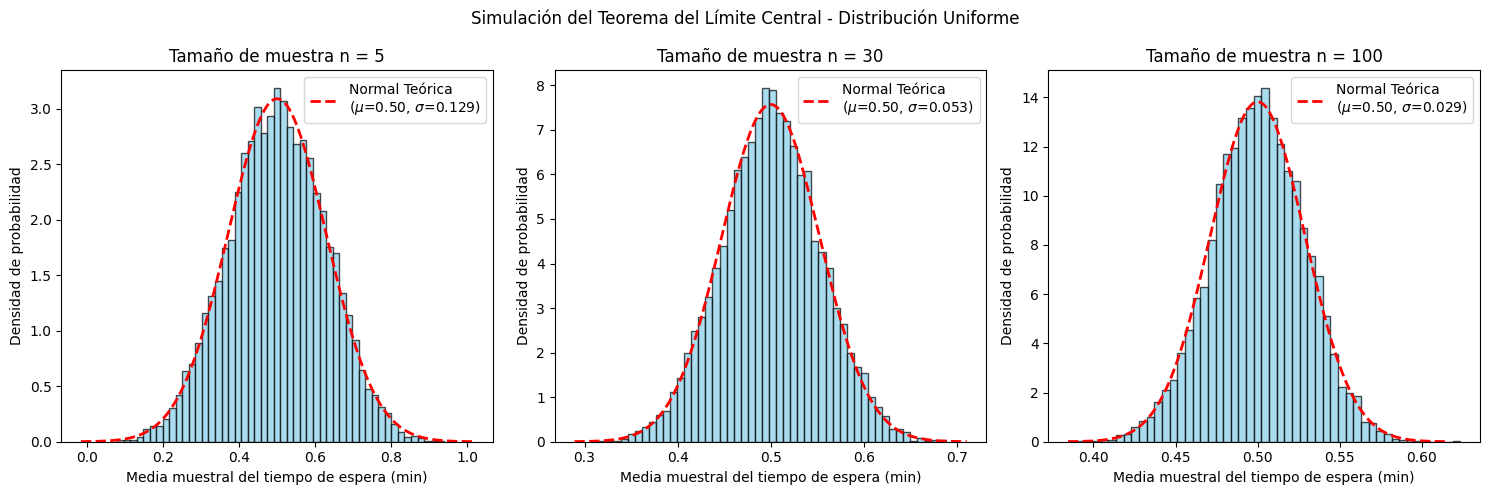

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parametros del experimento
num_replicas = 10000
sample_sizes = [5, 30 , 100]
a,b = 0,1 # Intervalo de la distribucion uniforme (EN MINUTOS)

# generar las medias muestrales para cada tamaño de muesrta
sample_means = {}
for n in sample_sizes:
    # Generar 10000 (num_replicas) muestras de tamaño n y calcular su media
    means = np.mean(np.random.uniform(a,b, size =(num_replicas,n)), axis = 1)
    sample_means[n] = means

# Mostrar el comportamiento de las medias muestrales
# Configurar la figura para los subplots
fig, axes = plt.subplots(1,3 , figsize =(15,5))
fig.suptitle("Simulación del Teorema del Límite Central - Distribución Uniforme")

# Colores para las curvas teoricas
colors = ["red", "green", "blue"]

for idx, n in enumerate(sample_sizes):
    ax = axes[idx]
    means = sample_means[n]

    # Grafiquemos el histograma de medias muestrales
    count, bins, ignored =  ax.hist(means, bins = 50, density = True, alpha = 0.7, color = "skyblue", edgecolor = "black")

    # Calcular los parametros de la distribucion normal teorica (por TLC)
    mu = (a+b)/2
    sigma = (b-a)/np.sqrt(12*n)

    # Curva de densidad normal teorica
    x = np.linspace(mu - 4*sigma , mu+4*sigma, 1000)
    y = stats.norm.pdf(x, mu, sigma)
    ax.plot(x,y,"r--",  linewidth = 2, label = f"Normal Teórica\n($\\mu$={mu:.2f}, $\\sigma$={sigma:.3f})")

    # Agreguemos titulo y etiquetas
    ax.set_title(f"Tamaño de muestra n = {n}")
    ax.set_xlabel("Media muestral del tiempo de espera (min)")
    ax.set_ylabel("Densidad de probabilidad")
    ax.legend()

# Fin
plt.tight_layout()
plt.show()

# Ejemplito 02:

**Enunciado**: El ingreso anual de individuos en una población, donde el logaritmo del ingreso es normal.

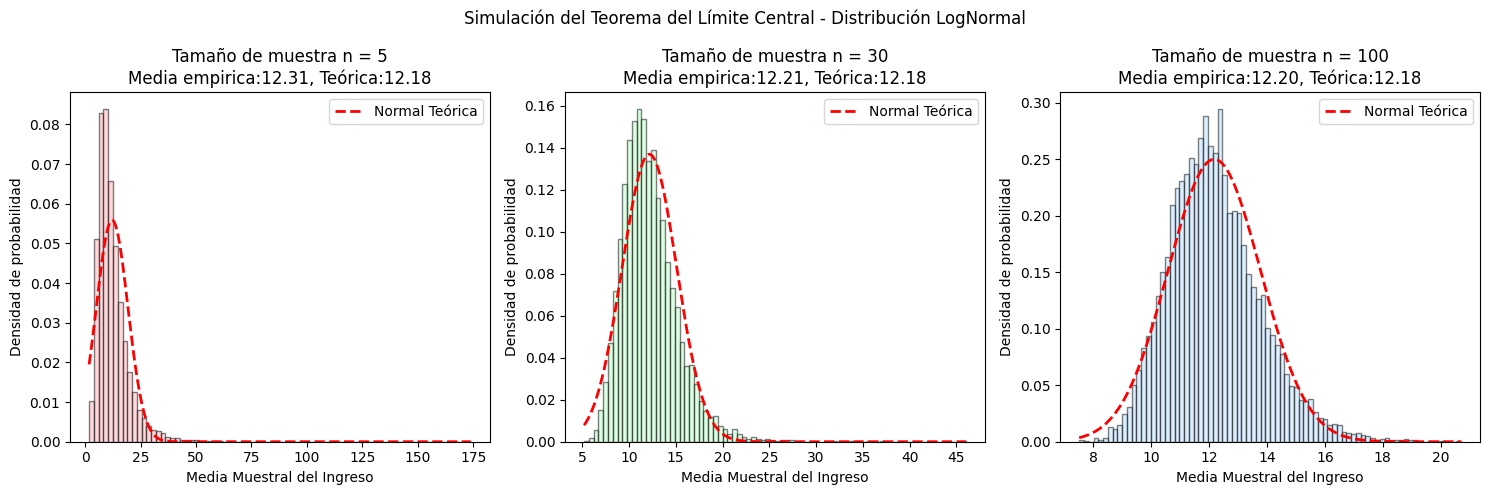

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parámetros del experimento
num_replicas = 10000
sample_sizes = [5, 30 , 100]
mu_log, sigma_log = 2,1 # media y desviacióon estandar del logaritmo del ingreso

# Generar las medias muestrales para cada tamaño de muestra
sample_means = {}
for n in sample_sizes:
  # Generar 10000 (num_replicas) de observaciones lognormales
  means = np.mean(np.random.lognormal(mean= mu_log, sigma= sigma_log, size =(num_replicas,n)), axis = 1)
  sample_means[n] = means

# Media y varianza teóricas de la distribución lognormal original
# Esperanza
mu_pop = np.exp(mu_log + sigma_log**2 / 2) # Media poblacional
# Varianza
var_pop = (np.exp(sigma_log**2) -1) * np.exp(2 *mu_log + sigma_log**2) # Varianza poblacional

# Mostrar el comportamiento de las medias muestrales
# Configurar la figura para los subplots
fig, axes = plt.subplots(1,3 , figsize =(15,5))
fig.suptitle("Simulación del Teorema del Límite Central - Distribución LogNormal")

# Colores para las curvas teoricas
colors = ['#ffb3ba', '#baffc9', '#bae1ff']

for idx, n in enumerate(sample_sizes):
    ax = axes[idx]
    means = sample_means[n]

    # Grafiquemos el histograma de medias muestrales
    count, bins, _ =  ax.hist(means, bins = 80, density = True, alpha = 0.5, color = colors[idx], edgecolor = "black")

    # Calcular los parametros de la distribucion normal teorica (por TLC)
    mu_mean = mu_pop
    sigma_mean = np.sqrt(var_pop / n)

    # Curva de densidad normal teorica
    x = np.linspace(bins[0], bins[-1], 1000)
    normal_pdf = (1/(sigma_mean * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x- mu_mean)/ sigma_mean)**2)
    ax.plot(x,normal_pdf,"r--",  linewidth = 2, label = f"Normal Teórica")

    # Agreguemos titulo y etiquetas
    ax.set_title(f"Tamaño de muestra n = {n}\nMedia empirica:{means.mean():.2f}, Teórica:{mu_mean:.2f}")
    ax.set_xlabel("Media Muestral del Ingreso")
    ax.set_ylabel("Densidad de probabilidad")
    ax.legend()

# Fin
plt.tight_layout()
plt.show()

Ver la velocidad de convergencia con Kolmogorov - Smirnov

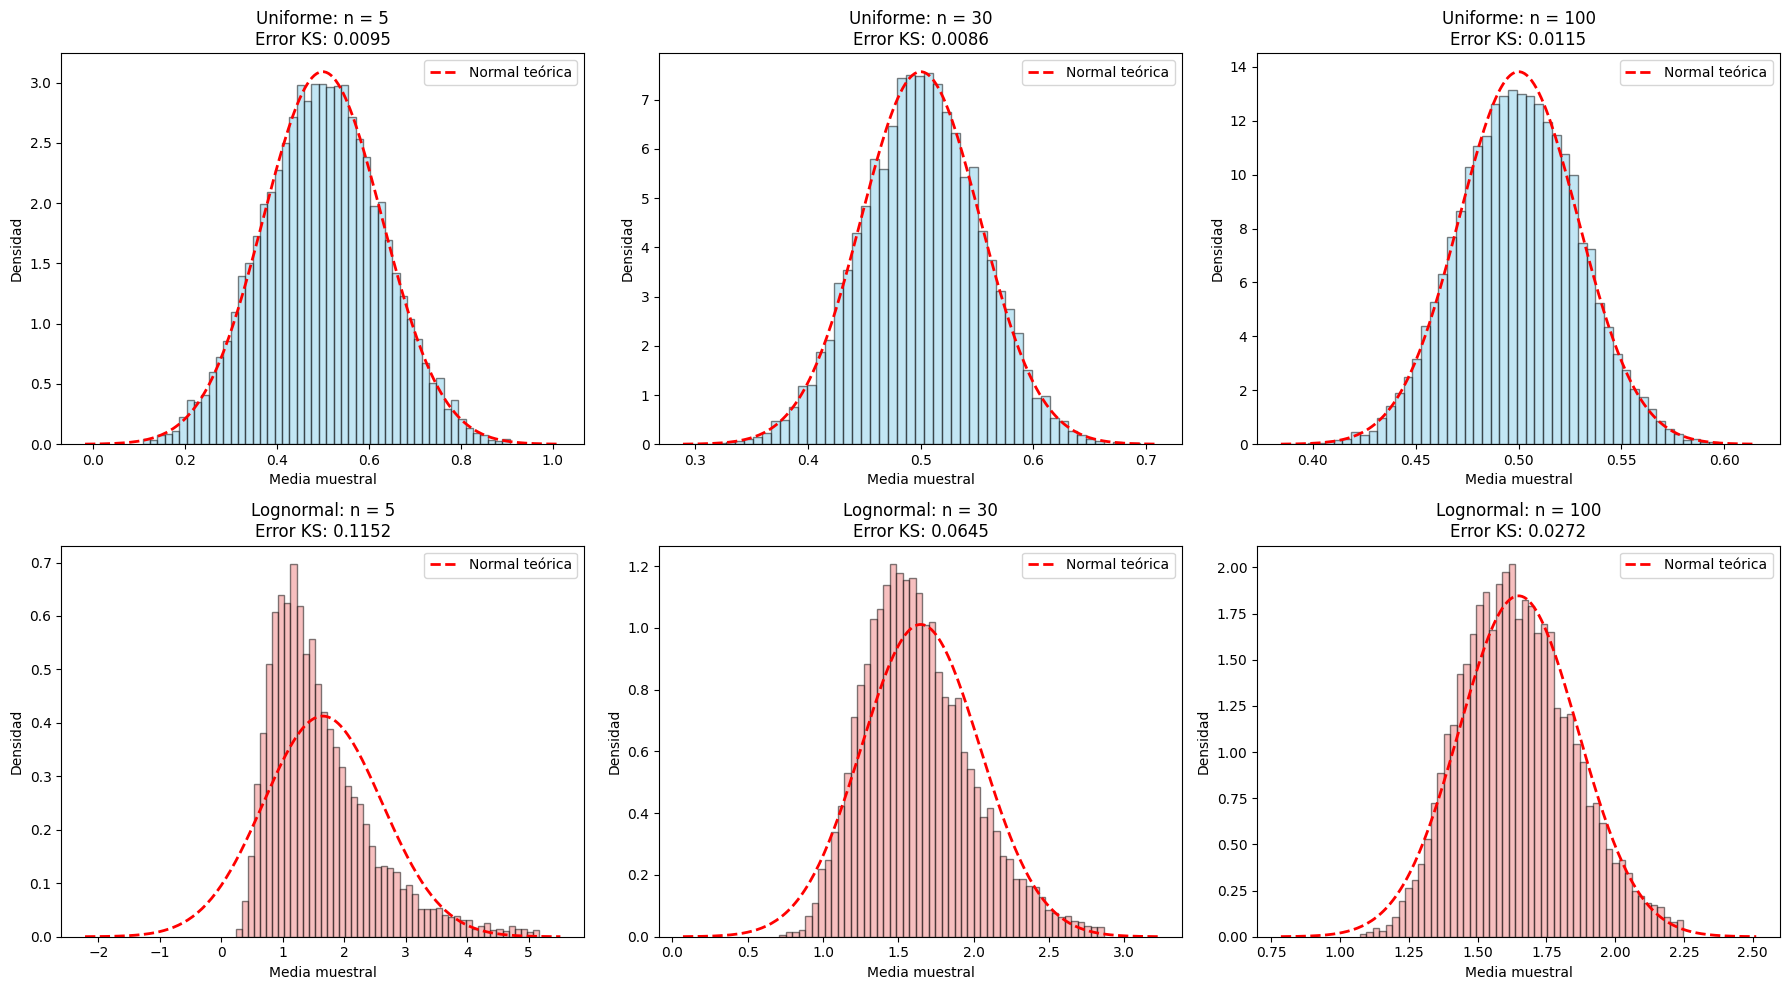

Comparación de velocidades de convergencia (Error de Kolmogorov-Smirnov):
-----------------------------------------------------------------
Tamaño de muestra (n) Uniforme        Lognormal      
-----------------------------------------------------------------
5                    0.0095          0.1152         
30                   0.0086          0.0645         
100                  0.0115          0.0272         
-----------------------------------------------------------------
Un error KS más pequeño indica una convergencia más rápida a la normalidad.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parámetros comunes
np.random.seed(42)
replicas = 10000
sample_sizes = [5, 30, 100]

# --- Distribución Uniforme U(0,1) ---
# Media y varianza teóricas
mu_unif = 0.5
var_unif = 1/12

uniform_means = {}
for n in sample_sizes:
    samples = np.random.uniform(0, 1, size=(replicas, n))
    uniform_means[n] = np.mean(samples, axis=1)

# --- Distribución Lognormal (parámetros para log(X) ~ N(0,1)) ---
# Si log(X) ~ N(0,1), entonces X ~ Lognormal(0,1)
# Media y varianza teóricas de X
mu_log = np.exp(0.5)      # ≈ 1.6487
var_log = (np.exp(1) - 1) * np.exp(1)  # ≈ 4.6708

lognormal_means = {}
for n in sample_sizes:
    samples = np.random.lognormal(mean=0, sigma=1, size=(replicas, n))
    lognormal_means[n] = np.mean(samples, axis=1)

# --- Cálculo del error de Kolmogorov-Smirnov (KS) ---
# Este error mide la distancia máxima entre la CDF empírica y la CDF teórica normal.
ks_errors = {'Uniform': [], 'Lognormal': []}

for n in sample_sizes:
    # Para la Uniforme
    means_unif = uniform_means[n]
    se_unif = np.sqrt(var_unif / n)
    ks_unif, _ = stats.kstest(means_unif, 'norm', args=(mu_unif, se_unif))
    ks_errors['Uniform'].append(ks_unif)

    # Para la Lognormal
    means_log = lognormal_means[n]
    se_log = np.sqrt(var_log / n)
    ks_log, _ = stats.kstest(means_log, 'norm', args=(mu_log, se_log))
    ks_errors['Lognormal'].append(ks_log)

# --- Visualización ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Gráficos de histogramas
for i, n in enumerate(sample_sizes):
    # Uniforme
    ax = axes[0, i]
    ax.hist(uniform_means[n], bins=50, density=True, alpha=0.5, color='skyblue', edgecolor='black')
    x = np.linspace(mu_unif - 4*np.sqrt(var_unif/n), mu_unif + 4*np.sqrt(var_unif/n), 200)
    y = stats.norm.pdf(x, mu_unif, np.sqrt(var_unif/n))
    ax.plot(x, y, 'r--', linewidth=2, label='Normal teórica')
    ax.set_title(f'Uniforme: n = {n}\nError KS: {ks_errors["Uniform"][i]:.4f}')
    ax.set_xlabel('Media muestral')
    ax.set_ylabel('Densidad')
    ax.legend()

    # Lognormal
    ax = axes[1, i]
    # Para visualizar mejor, truncamos los valores extremos en el gráfico (no en los cálculos)
    means_trunc = lognormal_means[n][lognormal_means[n] < np.percentile(lognormal_means[n], 99)]
    ax.hist(means_trunc, bins=50, density=True, alpha=0.5, color='lightcoral', edgecolor='black')
    x = np.linspace(mu_log - 4*np.sqrt(var_log/n), mu_log + 4*np.sqrt(var_log/n), 200)
    y = stats.norm.pdf(x, mu_log, np.sqrt(var_log/n))
    ax.plot(x, y, 'r--', linewidth=2, label='Normal teórica')
    ax.set_title(f'Lognormal: n = {n}\nError KS: {ks_errors["Lognormal"][i]:.4f}')
    ax.set_xlabel('Media muestral')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.tight_layout()
plt.show()

# --- Tabla de comparación de errores KS ---
print("Comparación de velocidades de convergencia (Error de Kolmogorov-Smirnov):")
print("-" * 65)
print(f"{'Tamaño de muestra (n)':<20} {'Uniforme':<15} {'Lognormal':<15}")
print("-" * 65)
for i, n in enumerate(sample_sizes):
    print(f"{n:<20} {ks_errors['Uniform'][i]:<15.4f} {ks_errors['Lognormal'][i]:<15.4f}")
print("-" * 65)
print("Un error KS más pequeño indica una convergencia más rápida a la normalidad.")

# Sklearn

In [21]:
from sklearn.linear_model import LinearRegression, LogisticRegression

In [22]:
# Documentacion de LinearRegression
help(LinearRegression)

Help on class LinearRegression in module sklearn.linear_model._base:

class LinearRegression(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, LinearModel)
 |  LinearRegression(*, fit_intercept=True, copy_X=True, n_jobs=None, positive=False)
 |
 |  Ordinary least squares Linear Regression.
 |
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |
 |  copy_X : bool, default=True
 |      If True, X will be copied; else, it may be overwritten.
 |
 |  n_jobs : int, default=None
 |      The number of jobs to use for the computation. This will only provide
 |      speedu

In [23]:
# Documentacion de LogisticRegression
help(LogisticRegression)

Help on class LogisticRegression in module sklearn.linear_model._logistic:

class LogisticRegression(sklearn.linear_model._base.LinearClassifierMixin, sklearn.linear_model._base.SparseCoefMixin, sklearn.base.BaseEstimator)
 |  LogisticRegression(penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)
 |
 |  Logistic Regression (aka logit, MaxEnt) classifier.
 |
 |  This class implements regularized logistic regression using the
 |  'liblinear' library, 'newton-cg', 'sag', 'saga' and 'lbfgs' solvers. **Note
 |  that regularization is applied by default**. It can handle both dense
 |  and sparse input. Use C-ordered arrays or CSR matrices containing 64-bit
 |  floats for optimal performance; any other input format will be converted
 |  (and copied).
 |
 |  The 'newton-cg', 'sag', and 'lbfgs' solvers support